# 12 · 다변량 Gaussian에서 entropy·KL·추정으로

**이번 질문:** 평균과 공분산만으로 점을 만들고 로그 밀도를 잴 수 있을까요? 두 분포가 얼마나 다른지를 숫자 하나로 재고, 그 숫자를 미분할 수 있을까요?

11번의 공분산을 **샘플 생성**과 **로그 밀도**에 씁니다. 그다음 정보량의 평균인 entropy, 예측 분포로 잰 cross-entropy, 그 차이인 KL을 같은 합으로 보고, 관측에서 Gaussian의 파라미터를 학습(MLE·MAP)한 뒤, 두 대각 Gaussian의 KL을 직접 구현·미분합니다.
이 계산은 VAE의 잠재분포와 diffusion의 잡음 분포로 연결됩니다.

- 준비물: [02](../00_기초/02_probability_and_losses.ipynb)의 우도·기댓값·CE, [11](11_linear_algebra.ipynb)의 공분산·행렬곱.
- 도착점: Gaussian 샘플·로그 밀도·entropy·KL·MLE·MAP·재매개화를 직접 쓰고 해석식·Monte Carlo·중심차분으로 검산합니다.
- 다음 연결: [13 자동미분](13_autodiff.ipynb)에서 이런 국소 미분을 계산 그래프에 연결합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 상관 있는 Gaussian 점은 독립 잡음을 선형 변환한 것입니다. $\Sigma=LL^\top$이면 `X = eps @ L.T + mu`. 로그 밀도는 상수·부피($\log\det\Sigma$)·표준화한 제곱 거리 세 항의 합에 $-\frac12$을 곱한 것입니다.
2. $H(p,q)=H(p)+KL(p\|q)$. entropy는 자기 자신으로 잰 평균 정보량, CE는 예측 $q$로 잰 것, KL은 그 차이이며 0 이상입니다. 평균은 **첫 분포 $p$**로 냅니다. 분류 CE는 정답 one-hot을 $p$로 둔 특수한 경우입니다.
3. 대각 Gaussian의 MLE는 관측 평균과 분모 $N$의 분산이고, 두 대각 Gaussian의 KL은 닫힌 식 $\frac12\sum[\ell_p-\ell_q+(e^{\ell_q}+(\mu_q-\mu_p)^2)e^{-\ell_p}-1]$입니다. 재매개화 $z=\mu+e^{\ell/2}\epsilon$은 잡음을 고정해 $\mu,\ell$로 미분할 수 있게 합니다.

| 기호 | shape | 의미 |
|---|---|---|
| $X$ | $(N,D)$ | 관측 또는 샘플 |
| $\mu,\ell$ | $(D,)$ 또는 $(N,D)$ | 평균, 좌표별 분산의 자연로그 |
| $\Sigma$ | $(D,D)$ | 공분산 |
| $L$ | $(D,D)$ | $\Sigma=LL^T$인 아래삼각행렬 |

로그의 밑은 $e$이며 정보량의 단위는 nat입니다. $\ell=\log\sigma^2$이면 분산은 $e^\ell$, 표준편차는 $e^{\ell/2}$입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/gaussian_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(4절부터: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/gaussian_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.gaussian_plots import (
    plot_curves, plot_sampling_flow, plot_log_density, plot_entropy_examples, plot_ce_kl_curves, plot_class_gaussians,
    plot_two_covariances, plot_map_shrink, plot_gaussian_kl, plot_reparameterization, plot_kl_vs_mean,
)

# 3) 그림 설정. 배열 출력은 소수 5자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=5, suppress=True)

### 📎 이 노트북의 예시: 2차원 Gaussian, 예측 분포 세 개, MNIST 클래스별 Gaussian

- **2차원 Gaussian.** $L=\left[\begin{smallmatrix}2&0\\1&1\end{smallmatrix}\right]$, $\mu=(1,-2)$인 분포. 샘플·밀도·MLE를 손계산과 대조합니다.
- **예측 분포 세 개.** 숫자 10개 중 정답이 7일 때 "확신·애매·틀림"인 예측의 entropy와 CE를 봅니다.
- **MNIST 클래스별 Gaussian.** 5,000장을 숫자별로 나눠 평균 이미지와 표준편차 이미지를 만듭니다. 이것이 대각 Gaussian의 MLE입니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.
> - `np.bincount(mnist_y)`: 0부터 9까지 각 숫자가 몇 번 나오는지 센 `(10,)`.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)          # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_X_all, mnist_y_all, _, _ = load_mnist()                         # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X, mnist_y = mnist_X_all[:5000], mnist_y_all[:5000]            # (5000, 784), (5000,): 학습 집합 앞 5,000장
print("MNIST", mnist_X.shape, "· 숫자별 장수", np.bincount(mnist_y))

MNIST (5000, 784) · 숫자별 장수 [479 563 488 493 535 434 501 550 462 495]


## 🔑 1. 독립 잡음을 상관 있는 점으로 바꾸기

**이 절에서 가져갈 것:** 좌표마다 독립인 표준정규 잡음 $\epsilon$에 $L$을 곱하고 $\mu$를 더하면 공분산 $LL^\top$의 Gaussian 점이 됩니다. 원하는 $\Sigma$에서 $L$은 Cholesky 분해로 얻고, 관측을 행에 두면 `eps @ L.T + mu`입니다.

동전을 던지듯 좌표마다 따로 뽑은 잡음은 동그란 구름입니다. 이 구름을 $L$로 늘리고 기울이면 두 좌표가 함께 움직이는 타원 구름이 되고, $\mu$를 더하면 자리를 옮깁니다.

> **용어**
>
> - **Cholesky 분해**: 대칭 양의 정부호 $\Sigma$를 아래삼각행렬 $L$로 $\Sigma=LL^\top$처럼 쪼개는 것. `np.linalg.cholesky(Sigma)`.
> - **양의 정부호(positive definite)**: 0이 아닌 모든 $v$에서 $v^\top\Sigma v>0$. 모든 방향에 퍼짐이 있어 밀도가 공간 전체에 정의됩니다.

열벡터로 $\epsilon\sim\mathcal N(0,I)$, $x=\mu+L\epsilon$이면
$\mathbb E[x]=\mu$, $\operatorname{Cov}(x)=L\mathbb E[\epsilon\epsilon^T]L^T=LL^T$입니다.
관측을 **행에 저장**하면 같은 식이 `epsilon @ L.T + mu`입니다.

공분산이 대칭 양의 정부호이면 `np.linalg.cholesky`가 $\Sigma=LL^T$인 $L$을 반환합니다.
이 절에서는 공간 전체에 밀도를 가지는 Gaussian을 사용합니다.

손계산: $L=\left[\begin{smallmatrix}2&0\\1&1\end{smallmatrix}\right]$이면 $\Sigma=\left[\begin{smallmatrix}4&2\\2&2\end{smallmatrix}\right]$입니다.

> **코드**
>
> - `flow_eps @ flow_L.T + flow_mu`: 행마다 잡음 하나. 열벡터 식 x = μ + Lε를 행 저장에 맞게 전치한 것입니다.
> - `np.sqrt(np.diag(L @ L.T))`: 공분산의 대각선(좌표별 분산)의 제곱근 = 좌표별 표준편차. 공분산 0인 비교 구름을 만드는 데 씁니다.
> - `np.linalg.cholesky(Sigma)`: Σ = LLᵀ인 아래삼각 L. 대칭 양의 정부호가 아니면 오류를 냅니다.

In [3]:
flow_rng = np.random.default_rng(1200)
flow_L = np.array([[2., 0.], [1., 1.]])                              # (2, 2): 아래삼각 L
flow_mu = np.array([1., -2.])                                        # (2,): 평균
flow_eps = flow_rng.normal(size=(600, 2))                            # (600, 2): 독립 표준정규 잡음
flow_x = flow_eps @ flow_L.T + flow_mu                               # (600, 2): 공분산 L Lᵀ 의 점
flow_indep = flow_rng.normal(size=(600, 2)) * np.sqrt(np.diag(flow_L @ flow_L.T)) + flow_mu   # (600, 2): 같은 좌표별 분산, 공분산 0
flow_cov = (flow_x - flow_x.mean(axis=0)).T @ (flow_x - flow_x.mean(axis=0)) / 600           # (2, 2): 600점의 경험 공분산 (11번 2절)
print("L Lᵀ =", (flow_L @ flow_L.T).tolist(), "· 600점의 경험 공분산\n", flow_cov.round(2))

L Lᵀ = [[4.0, 2.0], [2.0, 2.0]] · 600점의 경험 공분산
 [[3.99 1.98]
 [1.98 2.01]]


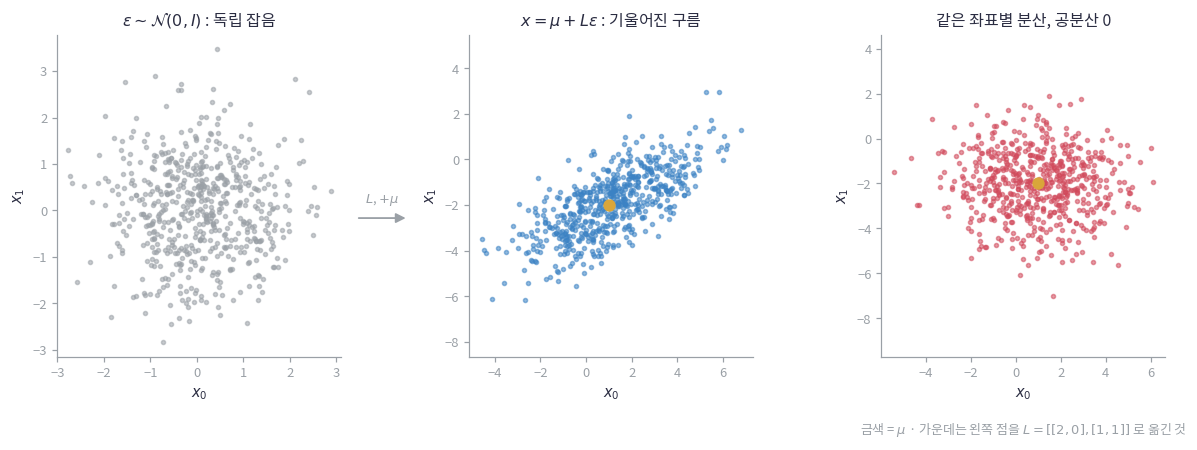

In [4]:
plot_sampling_flow(flow_eps, flow_x, flow_indep, flow_mu, flow_L)

🔍 **확인** · 왼쪽의 동그란 잡음이 $L$을 거쳐 가운데의 기울어진 구름이 됩니다. 두 좌표가 함께 커지는 관계가 공분산 2로 나타납니다. 오른쪽은 좌표별 분산은 같지만 공분산이 0이라 기울지 않은 구름입니다.
Gaussian에서는 대각 공분산이 좌표들의 독립성을 뜻합니다. 일반 분포의 공분산 0은 선형 상관이 0이라는 정보입니다. 아래 구현은 Cholesky로 $L$을 얻어 같은 식을 씁니다.

In [5]:
def sample_gaussian(mu, covariance, count, rng):
    """Gaussian 샘플 count개: ε ~ N(0, I)를 뽑아 ε Lᵀ + μ (Σ = LLᵀ는 Cholesky). mu: (D,), covariance: (D, D) → (count, D)."""
    L = np.linalg.cholesky(covariance)                      # (D, D): 아래삼각
    epsilon = rng.normal(size=(count, len(mu)))             # (count, D): 독립 표준정규
    return epsilon @ L.T + mu

In [6]:
# 쓰는 것: flow_mu, flow_L, flow_x (1절 그림 셀)
L_hand = np.array([[2., 0.], [1., 1.]])                     # (2, 2): 손계산 L
Sigma = L_hand @ L_hand.T                                   # (2, 2): Σ = LLᵀ. 2·4·5절도 이 분포를 씁니다
mu = np.array([1., -2.])                                    # (2,)
np.testing.assert_allclose(Sigma, [[4., 2.], [2., 2.]])    # 검산: 손계산 Σ
np.testing.assert_allclose(np.linalg.cholesky(Sigma), L_hand)   # 검산: Cholesky가 L을 되돌려 줌
rng = np.random.default_rng(120)                            # 이 노트북의 검산용 난수 생성기. 4·5·6절도 이어 씁니다
samples = sample_gaussian(mu, Sigma, 30000, rng)            # (30000, 2)
centered = samples - samples.mean(axis=0)
empirical_covariance = centered.T @ centered / len(samples) # (2, 2)
np.testing.assert_allclose(samples.mean(axis=0), mu, atol=.04)         # 검산: 표본 평균 ≈ μ
np.testing.assert_allclose(empirical_covariance, Sigma, atol=.09)      # 검산: 표본 공분산 ≈ Σ
print('생성 평균:', samples.mean(axis=0), '\n생성 공분산:\n', empirical_covariance)
np.testing.assert_allclose(sample_gaussian(flow_mu, flow_L @ flow_L.T, 600, np.random.default_rng(1200)), flow_x)   # 검산: 같은 seed면 위 그림의 점과 같음

생성 평균: [ 1.00867 -1.99173] 
생성 공분산:
 [[4.02464 1.98654]
 [1.98654 1.9867 ]]


🔍 **확인** · Cholesky가 손계산의 $L$을 그대로 돌려주고, 30,000점의 평균과 공분산이 $\mu$, $\Sigma$에 가깝습니다. 같은 seed의 잡음이면 위 그림의 점과 정확히 같습니다.

## 🔑 2. 로그 밀도: 거리와 부피

**이 절에서 가져갈 것:** $\log p(x)$는 세 항 $D\log2\pi$, $\log\det\Sigma$(분포의 부피), $(x-\mu)^\top\Sigma^{-1}(x-\mu)$(축별 크기로 잰 제곱 거리)의 합에 $-\frac12$을 곱한 것입니다. 점에 따라 바뀌는 것은 거리 항뿐입니다.

> **용어**
>
> - **행렬식(determinant)** $\det\Sigma$: 선형 변환이 부피를 몇 배로 만드는지. 삼각행렬에서는 대각 성분의 곱이라 $\log\det\Sigma=2\sum_j\log L_{jj}$.
> - **표준화한 제곱 거리** $(x-\mu)^\top\Sigma^{-1}(x-\mu)$: $u=L^{-1}(x-\mu)$의 제곱 길이. 퍼진 방향으로는 멀어도 작게, 좁은 방향으로는 가까워도 크게 셉니다.

$$\log p(x)=-\frac12\left[D\log(2\pi)+\log\det\Sigma+(x-\mu)^T\Sigma^{-1}(x-\mu)\right].$$

세 항은 차원에 따른 상수, 분포가 퍼진 부피, 분포의 축별 크기를 고려한 제곱 거리입니다.
$\Sigma=LL^T$에서 $u=L^{-1}(x-\mu)$를 구하면 마지막 항은 $\|u\|^2$입니다.
행렬식은 부피의 배율이고, 삼각행렬에서는 대각 성분들의 곱입니다. 따라서 $\log\det\Sigma=2\sum_j\log L_{jj}$입니다.
`solve(L, residual.T)`는 관측 각각에 대한 선형 방정식을 동시에 풉니다.

아래는 1절 분포의 로그 밀도를 격자에서 계산하고, 평균 A와 오른쪽으로 2만큼 떨어진 B의 세 항을 비교합니다.

> **코드**
>
> - `np.linalg.solve(Sigma, diff.T).T`: 관측마다 Σ⁻¹(x − μ)를 한 번에. `(D, N)`으로 세워 풀고 다시 눕힙니다. 역행렬을 만들지 않고 연립방정식을 푸는 쪽이 정확합니다.
> - `np.sum(diff * …, axis=1)`: 행마다 내적 = 관측마다 (x − μ)ᵀΣ⁻¹(x − μ).
> - `np.linalg.slogdet(Sigma)[1]`: 행렬식의 (부호, 로그 절댓값) 중 로그 절댓값. 큰 행렬에서 행렬식이 넘치지 않게 로그로 받습니다.
> - `np.diag(L)`: 삼각행렬의 대각 성분 `(D,)`. 그 로그의 합 × 2가 log det Σ입니다.

In [7]:
# 쓰는 것: mu, Sigma (1절 검산 셀)
dens_x0, dens_x1 = np.meshgrid(np.linspace(mu[0] - 6, mu[0] + 6, 121), np.linspace(mu[1] - 5, mu[1] + 5, 121))   # (121, 121) 둘: 격자
dens_diff = np.column_stack([dens_x0.ravel(), dens_x1.ravel()]) - mu           # (121², 2): x − μ
dens_d2 = np.sum(dens_diff * np.linalg.solve(Sigma, dens_diff.T).T, axis=1)    # (121²,): (x−μ)ᵀ Σ⁻¹ (x−μ)
dens_logdet = np.linalg.slogdet(Sigma)[1]                                       # log det Σ = log 4
dens_grid = (-0.5 * (2 * np.log(2 * np.pi) + dens_logdet + dens_d2)).reshape(dens_x0.shape)   # (121, 121): 격자의 로그 밀도
dens_points = np.array([mu, mu + [2., 0.]])                                     # (2, 2): A = 평균, B = 오른쪽으로 2
dens_pd = np.array([d @ np.linalg.solve(Sigma, d) for d in dens_points - mu])   # (2,): 두 점의 제곱 거리
dens_logpdfs = -0.5 * (2 * np.log(2 * np.pi) + dens_logdet + dens_pd)           # (2,): 두 점의 로그 밀도
dens_terms = [2 * np.log(2 * np.pi), dens_logdet, dens_pd[0], dens_pd[1]]       # 그림용: 상수 항, 부피 항, A·B의 거리 항
print("log det Σ =", dens_logdet.round(4), "· A, B 의 제곱 거리", dens_pd.round(3), "· log p(A), log p(B) =", dens_logpdfs.round(3))

log det Σ = 1.3863 · A, B 의 제곱 거리 [0. 2.] · log p(A), log p(B) = [-2.531 -3.531]


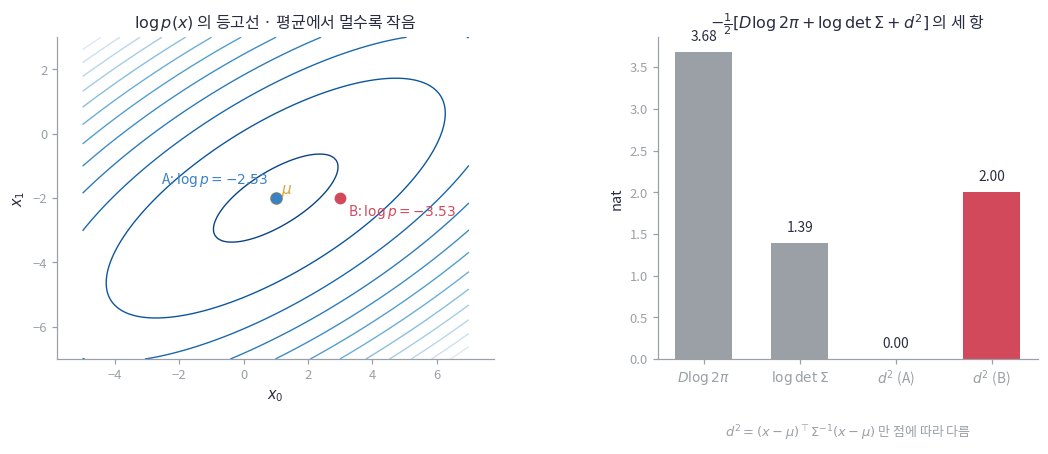

In [8]:
plot_log_density(dens_x0, dens_x1, dens_grid, mu, dens_points, dens_logpdfs, dens_terms)

🔍 **확인** · 등고선은 1절 구름과 같은 방향으로 기울어진 타원입니다. 평균 A에서 거리 항이 0이라 로그 밀도가 가장 크고, B는 오른쪽으로 2만큼 갔지만 구름이 퍼진 방향이 아니라서 제곱 거리가 2입니다. 상수 항과 부피 항은 점과 무관합니다.
아래 구현은 $L$로 풀어 제곱 거리를 얻고, 검산에서 `solve(Σ)`·`slogdet` 경로와 비교합니다.

In [9]:
def gaussian_logpdf(X, mu, covariance):
    """Gaussian 로그 밀도: −½[D log 2π + log det Σ + ‖L⁻¹(x − μ)‖²]. X: (N, D), mu: (D,), covariance: (D, D) → (N,)."""
    L = np.linalg.cholesky(covariance)                      # (D, D)
    standardized = np.linalg.solve(L, (X - mu).T).T         # (N, D): u = L⁻¹(x − μ)
    distance = np.sum(standardized**2, axis=1)              # (N,): ‖u‖² = (x−μ)ᵀΣ⁻¹(x−μ)
    log_determinant = 2 * np.log(np.diag(L)).sum()          # log det Σ = 2 Σ_j log L_jj
    return -.5 * (X.shape[1] * np.log(2 * np.pi) + log_determinant + distance)

In [10]:
# 쓰는 것: mu, Sigma, samples (1절 검산 셀) · dens_points, dens_logpdfs (2절 그림 셀)
at_mean = gaussian_logpdf(mu[None, :], mu, Sigma)           # 평균 위치: 거리 항 0
np.testing.assert_allclose(at_mean, [-np.log(2*np.pi) - np.log(2)])   # 검산: −½[2 log 2π + log 4] = −log 2π − log 2
points = samples[:5]                                        # (5, 2)
reference_distance = np.sum((points - mu) * np.linalg.solve(Sigma, (points - mu).T).T, axis=1)   # Σ⁻¹ 경로의 제곱 거리
_, reference_logdet = np.linalg.slogdet(Sigma)  # 행렬식의 부호와 로그 절댓값
reference_logpdf = -.5 * (2 * np.log(2*np.pi) + reference_logdet + reference_distance)
np.testing.assert_allclose(gaussian_logpdf(points, mu, Sigma), reference_logpdf)   # 검산: L 경로 = Σ⁻¹·slogdet 경로
print('평균 위치의 로그 밀도:', at_mean[0])
np.testing.assert_allclose(gaussian_logpdf(dens_points, mu, Sigma), dens_logpdfs)   # 검산: 위 그림의 A, B와 같음

평균 위치의 로그 밀도: -2.5310242469692907


🔍 **확인** · 평균 위치의 로그 밀도가 $-\log2\pi-\log2$이고, 다섯 점에서 $L$ 경로와 $\Sigma^{-1}$·`slogdet` 경로가 같습니다. 그림의 A·B 값도 같은 함수가 냅니다.

## 🔑 3. entropy·cross-entropy·KL을 같은 합으로 보기

**이 절에서 가져갈 것:** 사건 $i$의 정보량 $-\log p_i$를 $p$로 평균내면 entropy, 예측 $q$의 정보량 $-\log q_i$를 $p$로 평균내면 cross-entropy이고, 그 차이가 KL입니다. $H(p,q)=H(p)+KL(p\|q)$이며 KL은 0 이상이고 순서를 바꾸면 값이 다릅니다.

숫자를 맞히는 모델이 "7일 확률 0.91"이라고 답했을 때와 "열 숫자 모두 0.1"이라고 답했을 때, 정답이 7이면 어느 쪽이 더 놀라운(정보량이 큰) 관측일까요? 그리고 정답이 1이라면요?

> **용어**
>
> - **정보량** $-\log p_i$: 확률이 작은 사건일수록 큰 수. 단위는 nat(밑 $e$).
> - **entropy** $H(p)=-\sum_ip_i\log p_i$: 분포 $p$ 자신으로 잰 평균 정보량. 확신할수록 작고 고를수록 큽니다.
> - **cross-entropy** $H(p,q)=-\sum_ip_i\log q_i$: 관측은 $p$, 예측은 $q$일 때의 평균 정보량. **KL divergence** $D_{KL}(p\|q)=H(p,q)-H(p)$는 예측이 틀린 만큼의 추가 비용.

이산 분포 $p_i$에서 관측 $i$의 정보량을 $-\log p_i$로 정하면, 평균 정보량은
$H(p)=-\sum_i p_i\log p_i$입니다. 이를 **entropy**라고 합니다.
관측은 $p$를 따르고 예측에는 $q$를 쓰면 **cross-entropy** $H(p,q)=-\sum_i p_i\log q_i$입니다.
그 차이가 **KL divergence** 입니다.

$$D_{KL}(p\|q)=\sum_i p_i\log\frac{p_i}{q_i}=H(p,q)-H(p).$$

$\log u\le u-1$에 $u=q_i/p_i$를 대입하고 $p_i$로 가중합하면 $-D_{KL}(p\|q)\le\sum_{i:p_i>0}q_i-1\le0$이므로 KL은 0 이상입니다.
$D_{KL}(p\|q)$의 평균은 **첫 번째 분포 $p$**를 따릅니다. 순서를 바꾸면 값이 달라집니다.
$p_i=0$인 항은 기여 0, $p_i>0,q_i=0$인 항은 무한대입니다.

분류 라벨 하나를 확률 1인 분포로 보면 entropy는 0이며 CE는 $-\log q_y$가 됩니다. 여러 관측의 평균이 02의 분류 손실입니다.

아래는 정답이 7일 때 예측 분포 세 개의 entropy와 CE입니다.

> **코드**
>
> - `np.full(10, 0.01)` 뒤 `ent_sure[7] = 0.91`: 0.01로 채운 뒤 7번 칸만 0.91로. 합이 1인 확률 벡터입니다.
> - `[-np.sum(p * np.log(p)) for p in ent_dists]`: 분포마다 entropy를 계산해 목록으로.
> - `np.eye(10)[ent_target]`: 정답 자리만 1인 one-hot. 분류 라벨을 확률 1인 분포로 본 것입니다.
> - `p[active]`: `active = p > 0`인 자리만 골라 0·log 0을 피합니다. `np.any(np.isfinite(p))` 앞의 부정 연산자(물결표)는 "유한하지 않은 값이 하나라도 있는지"를 봅니다.

In [11]:
ent_target = 7                                                        # 정답
ent_sure = np.full(10, 0.01)                                          # (10,): 확신 (맞음)
ent_sure[7] = 0.91
ent_vague = np.full(10, 0.1)                                          # (10,): 애매
ent_wrong = np.full(10, 0.01)                                         # (10,): 확신 (틀림)
ent_wrong[1] = 0.91
ent_dists = [ent_sure, ent_vague, ent_wrong]
ent_H = [-np.sum(p * np.log(p)) for p in ent_dists]                    # 분포마다 entropy
ent_CE = [-np.log(p[ent_target]) for p in ent_dists]                   # 정답 one-hot 을 p 로 둔 CE = −log q_7
print("entropy:", np.round(ent_H, 3), "· CE(정답 7):", np.round(ent_CE, 3))

entropy: [0.5   2.303 0.5  ] · CE(정답 7): [0.094 2.303 4.605]


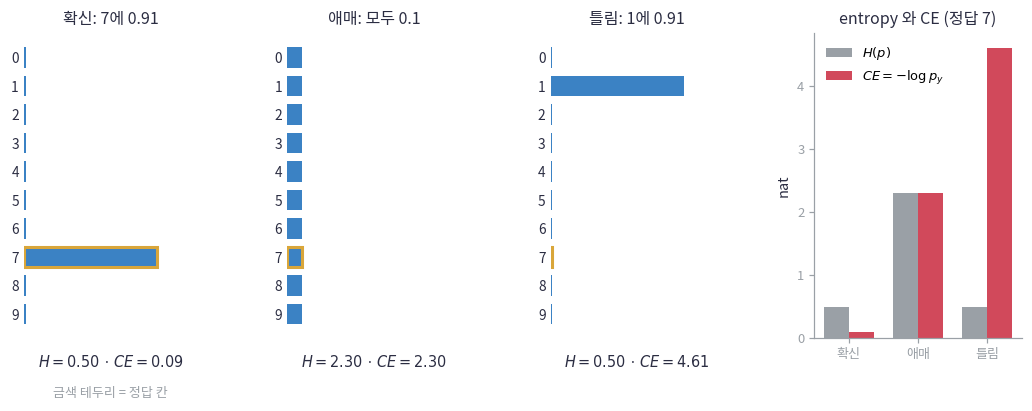

In [12]:
plot_entropy_examples(ent_dists, ["확신: 7에 0.91", "애매: 모두 0.1", "틀림: 1에 0.91"], ent_H, ent_CE, ent_target)

🔍 **확인** · entropy는 애매한 분포에서 가장 크고($\log10\approx2.30$), 확신하는 두 분포는 같습니다. 자기 자신으로 잰 정보량이라 어느 칸에 확신하는지는 상관없습니다.
CE는 정답 칸의 확률만 봅니다. 확신이 맞으면 작고, 틀리면 $-\log0.01\approx4.6$으로 큽니다. 02번의 분류 손실이 "틀린 확신"을 크게 벌하는 이유입니다. 아래 구현은 유한·비음수·합 1 검사를 포함합니다.

In [13]:
def check_distribution(p):
    """합이 1인 유한한 비음수 확률 벡터인지 확인하고 실수 배열로 돌려줍니다. p: (K,)."""
    p = np.asarray(p, dtype=float)
    if p.ndim != 1 or np.any(~np.isfinite(p)) or np.any(p < 0) or not np.isclose(p.sum(), 1):
        raise ValueError('합이 1인 유한한 비음수 확률 벡터를 사용합니다.')
    return p


def cross_entropy(p, q):
    """H(p, q) = −Σ_i p_i log q_i. p_i = 0인 항은 0, p_i > 0인데 q_i = 0이면 무한대. p, q: (K,) → 숫자 하나."""
    p, q = check_distribution(p), check_distribution(q)
    if p.shape != q.shape:
        raise ValueError('p와 q는 같은 사건들을 나타냅니다.')
    active = p > 0                                          # p_i > 0인 자리만
    if np.any(q[active] == 0):
        return np.inf
    return -np.sum(p[active] * np.log(q[active]))


def entropy(p):
    """H(p) = H(p, p) = −Σ_i p_i log p_i. p: (K,) → 숫자 하나."""
    return cross_entropy(p, p)


def categorical_kl(p, q):
    """D_KL(p‖q) = H(p, q) − H(p). p, q: (K,) → 숫자 하나 (0 이상)."""
    return cross_entropy(p, q) - entropy(p)

In [14]:
# 쓰는 것: ent_dists, ent_H, ent_CE, ent_sure, ent_target (3절 그림 셀)
p = np.array([.75, .25])                                    # 관측 분포
q = np.array([.5, .5])                                      # 예측 분포
hand_kl = .75 * np.log(1.5) + .25 * np.log(.5)              # 손계산 Σ p_i log(p_i/q_i)
np.testing.assert_allclose(categorical_kl(p, q), hand_kl)   # 검산: 손계산
assert not np.isclose(categorical_kl(p, q), categorical_kl(q, p)), "KL은 순서를 바꾸면 값이 달라야 합니다"
assert entropy([1., 0.]) == 0, "확률 1인 분포의 entropy는 0이어야 합니다"
assert np.isinf(categorical_kl([1., 0.], [0., 1.])), "p > 0인 자리에 q = 0이면 KL은 무한대여야 합니다"
np.testing.assert_allclose(entropy([.5, .5]), np.log(2))    # 검산: 균등 2칸의 entropy = log 2
print(f'H(p)={entropy(p):.6f}, H(p,q)={cross_entropy(p,q):.6f}, KL(p||q)={hand_kl:.6f}')
for p_ex, h_ex in zip(ent_dists, ent_H):
    np.testing.assert_allclose(entropy(p_ex), h_ex)                    # 검산: 위 그림의 entropy
np.testing.assert_allclose(cross_entropy(np.eye(10)[ent_target], ent_sure), ent_CE[0])   # 검산: 정답 one-hot 의 CE

H(p)=0.562335, H(p,q)=0.693147, KL(p||q)=0.130812


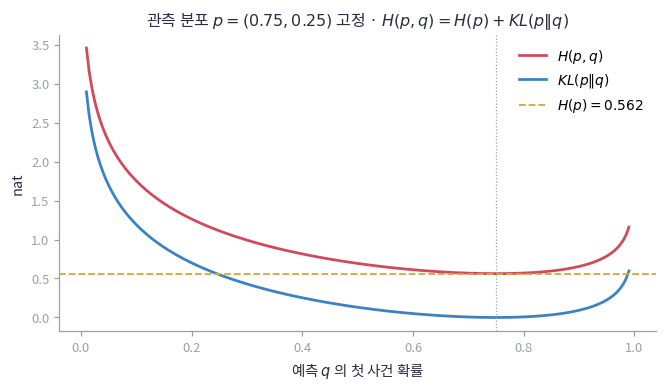

In [15]:
probabilities = np.linspace(.01, .99, 199)                  # (199,): 그림용. 예측 q = [값, 1 − 값]
ce_curve = np.array([cross_entropy(p, [value, 1-value]) for value in probabilities])   # (199,): H(p, q)
kl_curve = np.array([categorical_kl(p, [value, 1-value]) for value in probabilities])  # (199,): KL(p‖q)
plot_ce_kl_curves(probabilities, ce_curve, kl_curve, entropy(p))

🔍 **확인** · 두 곡선의 차이는 항상 $H(p)$입니다. 고정된 관측 분포에서 CE를 줄이면 KL도 같은 만큼 줄어들고, $q=p$일 때 KL이 0으로 최소입니다.

📎 연속 분포에서는 합이 적분, 확률이 밀도로 바뀝니다. 밀도값은 1보다 클 수 있어 **미분 entropy** $-\mathbb E[\log p(X)]$는 음수도 가능합니다.
Gaussian에서는 $h=\tfrac12[D(1+\log(2\pi))+\log\det\Sigma]$입니다. 표준화된 제곱 거리의 기댓값이 $D$라는 사실을 로그 밀도에 대입해 얻습니다. 아래에서 샘플 평균과 대조합니다.

In [16]:
# 쓰는 것: Sigma, mu, samples (1절 검산 셀) · gaussian_logpdf (2절)
gaus_entropy = .5 * (2 * (1 + np.log(2*np.pi)) + np.linalg.slogdet(Sigma)[1])   # 해석식 h = ½[D(1 + log 2π) + log det Σ]
monte_carlo_entropy = -gaussian_logpdf(samples, mu, Sigma).mean()                # 샘플 30,000개의 −log p 평균
assert abs(gaus_entropy - monte_carlo_entropy) < .03, "샘플 평균이 해석식과 0.03 안에서 같아야 합니다"
print('Gaussian entropy 해석식 / 샘플 평균:', gaus_entropy, monte_carlo_entropy)

Gaussian entropy 해석식 / 샘플 평균: 3.5310242469692907 3.5372813163988632


## 🔑 4. 관측에서 Gaussian 학습하기: MLE와 MAP

**이 절에서 가져갈 것:** 대각 Gaussian의 음의 로그 밀도를 관측 평균으로 만든 손실을 기울기로 내리면, 평균은 관측 평균, 분산은 분모 $N$의 관측 분산으로 갑니다. 이 닫힌 해가 MLE이고, 손실은 **관측 축에서 평균, 좌표 축에서 합**입니다.

숫자 7 이미지들만 모아 "7은 대체로 이렇게 생겼고 화소마다 이만큼 흔들린다"를 평균 이미지와 표준편차 이미지로 적는 것이 대각 Gaussian의 MLE입니다.

> **용어**
>
> - **MLE(최대우도 추정)**: 관측의 로그 밀도 합(또는 평균)을 가장 크게 하는 파라미터. 음의 로그 밀도(NLL)를 최소화하는 것과 같습니다.
> - **대각 Gaussian**: 공분산이 $\mathrm{diag}(e^{\ell_1},\ldots,e^{\ell_D})$인 분포. 좌표마다 평균·분산만 있고 좌표 사이의 공분산은 0입니다.

대각 공분산 $\operatorname{diag}(e^{\ell_1},\ldots,e^{\ell_D})$를 사용하면 관측 하나의 음의 로그 밀도는
$\tfrac12\sum_j[\log(2\pi)+\ell_j+(x_j-\mu_j)^2e^{-\ell_j}]$입니다.
**MLE(최대우도 추정)** 는 관측 평균 NLL을 최소화합니다.

$$\partial_{\mu_j}L=\frac1N\sum_n(\mu_j-X_{nj})e^{-\ell_j},\qquad
\partial_{\ell_j}L=\frac12\left[1-\frac1N\sum_n(X_{nj}-\mu_j)^2e^{-\ell_j}\right].$$

이를 0으로 놓으면 평균은 관측 평균, 분산은 분모 $N$의 관측 분산이 됩니다. 기울기 학습 결과를 이 해석해와 비교합니다.
손실은 **관측 축에서 평균, 좌표 축에서 합**입니다.

아래는 MNIST 5,000장을 숫자별로 나눠 닫힌 해로 구한 $\mu_c$와 $\sigma_c$입니다.

> **코드**
>
> - `np.stack([mnist_X[mnist_y == c].mean(axis=0) for c in range(10)])`: 숫자 c마다 그 이미지들만 골라(마스크) 화소별 평균을 내고 10개를 행으로 쌓아 `(10, 784)`. `.std(axis=0)`은 분모 N의 표준편차입니다.
> - `np.exp(-logvar)`: 분산의 역수 e^−ℓ. 로그 분산으로 두면 분산이 항상 양수입니다.

In [17]:
# 쓰는 것: mnist_X, mnist_y (📎 데이터 셀)
class_means = np.stack([mnist_X[mnist_y == c].mean(axis=0) for c in range(10)])   # (10, 784): 숫자별 MLE 평균
class_stds = np.stack([mnist_X[mnist_y == c].std(axis=0) for c in range(10)])     # (10, 784): 숫자별 MLE 표준편차 (분모 N)
print("평균 이미지", class_means.shape, "· 7의 표준편차 최대", class_stds[7].max().round(3), "· 항상 흰 화소(σ=0)", int((class_stds[7] == 0).sum()), "개")

평균 이미지 (10, 784) · 7의 표준편차 최대 0.451 · 항상 흰 화소(σ=0) 277 개


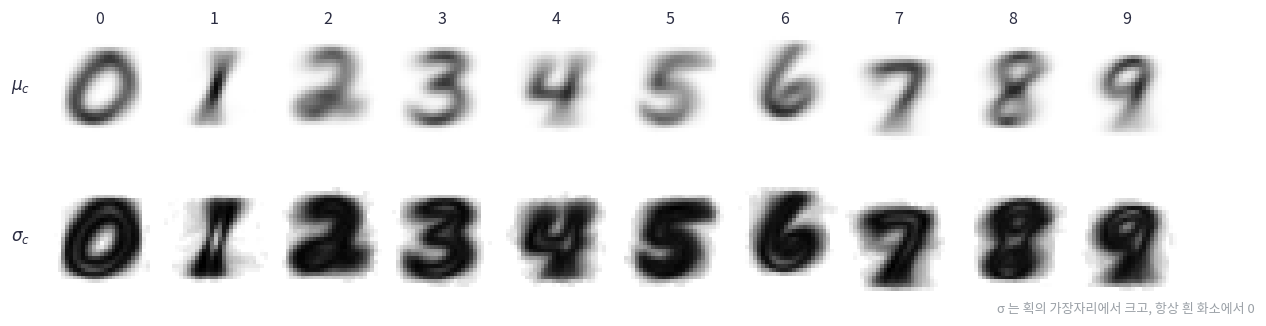

In [18]:
plot_class_gaussians(class_means.reshape(10, 28, 28), class_stds.reshape(10, 28, 28), range(10))

🔍 **확인** · 위 행이 숫자마다의 평균 이미지 $\mu_c$, 아래 행이 표준편차 이미지 $\sigma_c$입니다. 표준편차는 획의 가장자리(사람마다 위치가 다른 곳)에서 크고, 항상 흰 화소에서 0입니다.
분산이 0인 화소는 로그 밀도의 $e^{-\ell}$이 무한대가 되므로 실제 분류기에는 작은 값을 더해 씁니다. 아래 구현은 2차원 관측에서 같은 NLL을 기울기로 내려 닫힌 해에 도달하는지 봅니다.

In [19]:
def diagonal_nll(X, mu, logvar):
    """대각 Gaussian의 관측 평균 NLL과 두 기울기: L = ½ mean_n Σ_j [log 2π + ℓ_j + (x_nj − μ_j)² e^−ℓ_j].
    X: (N, D), mu, logvar: (D,) → (L: 숫자, dmu: (D,), dlogvar: (D,))."""
    residual = mu - X                                       # (N, D): μ − x
    inverse_variance = np.exp(-logvar)                      # (D,): e^−ℓ
    loss = .5 * np.mean(np.sum(np.log(2*np.pi) + logvar + residual**2 * inverse_variance, axis=1))   # 좌표 축 합, 관측 축 평균
    dmu = residual.mean(axis=0) * inverse_variance          # (D,): ∂L/∂μ_j = mean_n(μ_j − x_nj) e^−ℓ_j
    dlogvar = .5 * (1 - (residual**2).mean(axis=0) * inverse_variance)   # (D,): ∂L/∂ℓ_j = ½[1 − mean_n(x_nj − μ_j)² e^−ℓ_j]
    return loss, dmu, dlogvar

In [20]:
# 쓰는 것: mu, Sigma, rng (1절 검산 셀) · sample_gaussian (1절)
X_fit = sample_gaussian(mu, Sigma, 600, rng)                # (600, 2): 학습 관측
X_holdout = sample_gaussian(mu, Sigma, 400, rng)            # (400, 2): 검증 관측
mu_fit = np.array([-.3, .4])                                # 학습할 평균의 시작값
logvar_fit = np.array([.2, -.1])                            # 학습할 로그 분산의 시작값
loss, dmu, dlogvar = diagonal_nll(X_fit, mu_fit, logvar_fit)


def nll_scalar():
    """검사기용: 시작값에서의 NLL."""
    return diagonal_nll(X_fit, mu_fit, logvar_fit)[0]


grad_errors = [rel_error(dmu, numerical_gradient(nll_scalar, mu_fit)),           # 1. 두 기울기를 중심차분과 대조
               rel_error(dlogvar, numerical_gradient(nll_scalar, logvar_fit))]
assert max(grad_errors) < 1e-7, "두 기울기의 상대오차가 1e−7 아래여야 합니다"
history = []
for step in range(1200):                                    # 2. 경사하강 1,200스텝
    loss, dmu, dlogvar = diagonal_nll(X_fit, mu_fit, logvar_fit)
    history.append(loss)
    mu_fit -= .08 * dmu
    logvar_fit -= .08 * dlogvar
final_nll = diagonal_nll(X_fit, mu_fit, logvar_fit)[0]
np.testing.assert_allclose(mu_fit, X_fit.mean(axis=0), atol=1e-7)             # 검산: 학습한 평균 = 관측 평균 (MLE 닫힌 해)
np.testing.assert_allclose(np.exp(logvar_fit), X_fit.var(axis=0), atol=1e-7)  # 검산: 학습한 분산 = 관측 분산 (분모 N)
print('NLL:', history[0], '→', final_nll, '기울기 상대 오차:', max(grad_errors))
print('학습 평균:', mu_fit, '학습 분산:', np.exp(logvar_fit))
print('검증 대각 NLL:', diagonal_nll(X_holdout, mu_fit, logvar_fit)[0])

NLL: 8.55601464440519 → 3.8422006773846835 기울기 상대 오차: 4.682602983647733e-10
학습 평균: [ 1.02003 -2.05325] 학습 분산: [3.71229 2.00772]
검증 대각 NLL: 3.813318662994327


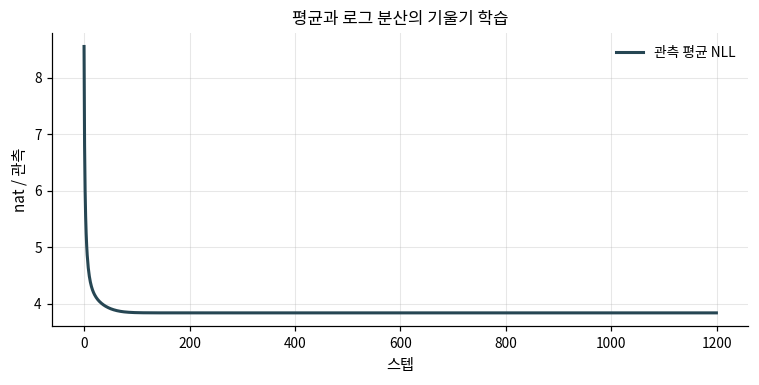

In [21]:
plot_curves(np.arange(len(history)), {'관측 평균 NLL': history}, title='평균과 로그 분산의 기울기 학습', ylabel='nat / 관측')

🔍 **확인** · 1,200스텝 뒤 학습한 평균과 분산이 관측 평균·분산(분모 $N$)과 $10^{-7}$ 안에서 같습니다. 두 기울기도 중심차분과 맞습니다.

대각 모형은 각 좌표의 분포를 평균·분산으로 요약하며, 좌표 사이의 공분산은 0으로 둡니다. 공분산 전체를 쓰는 모형은 비대각 성분까지 추정합니다.
아래에서 같은 학습 관측으로 두 모형을 맞추고 별도의 관측에서 비교합니다.

In [22]:
# 쓰는 것: gaussian_logpdf (2절) · X_fit, X_holdout, mu_fit, logvar_fit (4절 학습 셀)
fit_centered = X_fit - X_fit.mean(axis=0)
full_covariance = fit_centered.T @ fit_centered / len(X_fit)          # (2, 2): 전체 공분산의 MLE (11번 2절)
full_holdout_nll = -gaussian_logpdf(X_holdout, X_fit.mean(axis=0), full_covariance).mean()   # 검증 NLL (전체 공분산)
diagonal_holdout_nll = diagonal_nll(X_holdout, mu_fit, logvar_fit)[0]                        # 검증 NLL (대각)
print('검증 NLL 전체 공분산 / 대각 공분산:', full_holdout_nll, diagonal_holdout_nll)

검증 NLL 전체 공분산 / 대각 공분산: 3.491291280879719 3.813318662994327


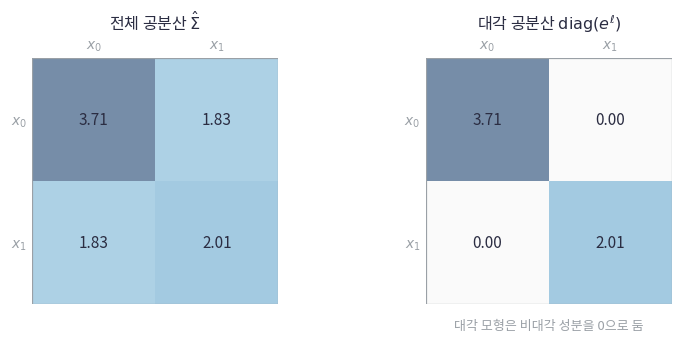

In [23]:
plot_two_covariances(full_covariance, np.diag(np.exp(logvar_fit)))

🔍 **확인** · 전체 공분산은 비대각 2 근처를 추정하지만 대각 모형은 그 자리를 0으로 둡니다. 데이터가 실제로 상관이 있으므로 검증 NLL은 전체 공분산 모형이 더 낮습니다.

### 🔑 사전분포가 붙으면 MAP

**이 절에서 가져갈 것:** 파라미터에 사전분포를 두면 NLL에 사전 항이 더해지고, 최솟점이 사전 평균 쪽으로 옮겨 갑니다. 이 추정이 MAP이며, 사전 분산 $\tau^2$이 작을수록 더 많이 끌려갑니다.

> **용어** · **MAP(최대사후 추정)·사전분포(prior)**: 관측 전에 파라미터가 따를 것이라 두는 분포 $p(\theta)$와, $p(\theta\mid x)\propto p(x\mid\theta)p(\theta)$를 가장 크게 하는 $\theta$.

스칼라 관측 $x_n\sim\mathcal N(\theta,\sigma^2)$와 사전분포 $\theta\sim\mathcal N(0,\tau^2)$를 정합니다.
Bayes 식 $p(\theta\mid x)\propto p(x\mid\theta)p(\theta)$에서 음의 로그를 취하면

$$J(\theta)=\frac1{2\sigma^2}\sum_n(x_n-\theta)^2+\frac{\theta^2}{2\tau^2}+\text{상수}.$$

이를 최소화하는 **MAP(최대사후 추정)** 는 $\theta_{MAP}=\sum_nx_n/(N+\sigma^2/\tau^2)$입니다.
MLE는 $\bar x$이고, MAP는 사전 평균 0 쪽으로 이동합니다. $J/N$으로 평균 규약을 바꾸면 사전 항의 계수도 $1/N$이 됩니다.
MAP는 사후분포의 최빈값 하나를 고르는 추정이며, 사후분포 전체를 얻는 계산으로도 이어집니다.

아래는 관측 `[1, 2, 3]`에서 $\tau^2$을 바꿀 때 MAP가 어디로 가는지입니다.

> **코드** · `map_observed.sum() / (len(map_observed) + map_sigma2 / map_tau2)`: τ²가 배열 `(4,)`이라 브로드캐스팅으로 τ²마다의 MAP 네 개가 한 번에 나옵니다.

In [24]:
map_observed = np.array([1., 2., 3.])                       # (3,): 관측
map_sigma2 = 1.                                             # 관측 분산 σ²
map_tau2 = np.array([0.1, 0.5, 2., 10.])                    # (4,): 사전 분산 τ² 네 가지
map_mle = map_observed.mean()                               # MLE = 관측 평균
map_estimates = map_observed.sum() / (len(map_observed) + map_sigma2 / map_tau2)   # (4,): τ² 마다의 MAP
print("MLE =", map_mle, "· τ² =", map_tau2, "→ MAP =", map_estimates.round(3))

MLE = 2.0 · τ² = [ 0.1  0.5  2.  10. ] → MAP = [0.462 1.2   1.714 1.935]


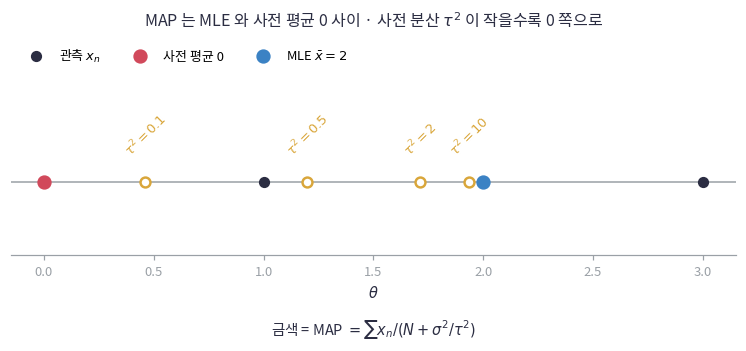

In [25]:
plot_map_shrink(map_observed, map_mle, map_tau2, map_estimates)

🔍 **확인** · MLE는 관측 평균 2입니다. 사전 분산 $\tau^2$이 작을수록(사전이 강할수록) MAP가 0 쪽으로 더 끌려가고, $\tau^2$이 크면 MLE에 가깝습니다. 아래 검산은 $\tau^2=0.5$에서 MAP가 1.2이고 그 자리에서 $J$의 미분이 0인지 봅니다.

In [26]:
# 쓰는 것: map_estimates (MAP 그림 셀)
observed = np.array([1., 2., 3.])
sigma2, tau2 = 1., .5
theta_mle = observed.mean()                                 # MLE
theta_map = observed.sum() / (len(observed) + sigma2 / tau2)   # MAP = Σx / (N + σ²/τ²)
np.testing.assert_allclose(theta_map, 1.2)                  # 검산: 6/(3 + 2)
stationary = np.sum(theta_map - observed) / sigma2 + theta_map / tau2   # J'(θ) at θ_MAP
np.testing.assert_allclose(stationary, 0, atol=1e-14)       # 검산: MAP에서 J의 미분이 0
print('MLE / MAP:', theta_mle, theta_map)
np.testing.assert_allclose(theta_map, map_estimates[1])     # 검산: 위 그림의 τ² = 0.5 점과 같음

MLE / MAP: 2.0 1.2


## 🔑 5. 대각 Gaussian KL: VAE를 읽을 준비

**이 절에서 가져갈 것:** 두 대각 Gaussian의 KL은 샘플 없이 닫힌 식으로 계산됩니다. 좌표마다 $\frac12[\ell_p-\ell_q+(e^{\ell_q}+(\mu_q-\mu_p)^2)e^{-\ell_p}-1]$를 더하고 관측 축에서 평균냅니다. 기댓값은 **$q$**로 내며, $q$의 파라미터로 미분할 수 있습니다.

> **용어** · **닫힌 식(closed form)**: 적분이나 샘플 없이 파라미터만으로 바로 쓸 수 있는 식. Gaussian 사이의 KL은 닫힌 식이 있어 VAE의 손실에 그대로 들어갑니다.

관측마다 $q_n(z)=\mathcal N(\mu_{q,n},\operatorname{diag}(e^{\ell_{q,n}}))$를 만들고,
$p(z)=\mathcal N(\mu_p,\operatorname{diag}(e^{\ell_p}))$와 비교합니다.
$D_{KL}(q\|p)=\mathbb E_q[\log q(z)-\log p(z)]$에 로그 밀도를 넣습니다.
$\mathbb E_q[(z_j-\mu_{p,j})^2]=e^{\ell_{q,j}}+(\mu_{q,j}-\mu_{p,j})^2$를 쓰면

$$K=\frac1{2N}\sum_{n,j}\left[\ell_{p,j}-\ell_{q,nj}
+\frac{e^{\ell_{q,nj}}+(\mu_{q,nj}-\mu_{p,j})^2}{e^{\ell_{p,j}}}-1\right].$$

고정된 $p$에 대한 미분은
$\partial_{\mu_q}K=(\mu_q-\mu_p)e^{-\ell_p}/N$,
$\partial_{\ell_q}K=(e^{\ell_q-\ell_p}-1)/(2N)$입니다.
$p$가 표준정규이면 $K=\tfrac1{2N}\sum(\mu_q^2+e^{\ell_q}-1-\ell_q)$로 단순해집니다.

아래는 1차원에서 $q=\mathcal N(1, 2)$, $p=\mathcal N(-0.3, 0.8)$의 밀도와, $q$로 가중한 $\log q-\log p$입니다. 그 적분이 KL입니다.

> **코드**
>
> - `np.trapezoid(y, x)`: 사다리꼴 규칙의 수치 적분 ∫ y dx. 닫힌 식과 대조할 값을 만듭니다.
> - `rng.normal(size=(100000, 2)) * np.exp(.5 * ql) + qm`: q에서 뽑은 샘플. 표준정규 × σ(= e^{ℓ/2}) + μ입니다(6절의 재매개화).
> - `np.diag(np.exp(ql))`: 로그 분산에서 대각 공분산 행렬을 만들어 2절의 `gaussian_logpdf`에 넣습니다.
> - `np.repeat(qm, 2, axis=0)`: 관측을 두 배로 되풀이. 관측 평균은 그대로, 관측별 기울기는 절반이 되어야 합니다.

In [27]:
kl_qmu, kl_qvar, kl_pmu, kl_pvar = 1., 2., -0.3, 0.8                                               # q = N(1, 2), p = N(−0.3, 0.8)
kl_x = np.linspace(-10, 12, 2201)                                                                  # (2201,): 꼬리까지 넓게 (q 의 꼬리에서 log 비가 큼)
kl_q = np.exp(-0.5 * (kl_x - kl_qmu) ** 2 / kl_qvar) / np.sqrt(2 * np.pi * kl_qvar)               # (2201,): q의 밀도
kl_p = np.exp(-0.5 * (kl_x - kl_pmu) ** 2 / kl_pvar) / np.sqrt(2 * np.pi * kl_pvar)               # (2201,): p의 밀도
kl_log_ratio = np.log(kl_q) - np.log(kl_p)                                                         # (2201,): log q − log p
kl_closed = 0.5 * (np.log(kl_pvar / kl_qvar) + (kl_qvar + (kl_qmu - kl_pmu) ** 2) / kl_pvar - 1)   # 닫힌 식
kl_numeric = np.trapezoid(kl_q * kl_log_ratio, kl_x)                                              # 적분 ∫ q (log q − log p) dx
np.testing.assert_allclose(kl_numeric, kl_closed, atol=1e-5)                                       # 검산: 수치 적분 = 닫힌 식
print("KL(q‖p) 닫힌 식 =", kl_closed.round(4), "· 수치 적분 =", kl_numeric.round(4))

KL(q‖p) 닫힌 식 = 1.3481 · 수치 적분 = 1.3481


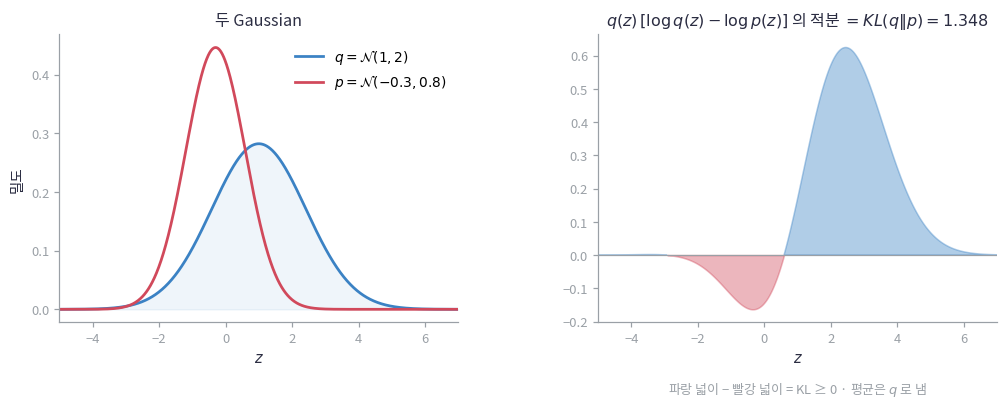

In [28]:
plot_gaussian_kl(kl_x, kl_q, kl_p, kl_log_ratio, kl_closed, "$q = \\mathcal{N}(1, 2)$", "$p = \\mathcal{N}(-0.3, 0.8)$")

🔍 **확인** · 오른쪽의 파란 넓이(q가 p보다 큰 곳)에서 빨간 넓이를 뺀 값이 KL이고, 닫힌 식과 수치 적분이 같습니다. $q$가 넓고 $p$가 좁으면 $q$의 꼬리에서 $\log q-\log p$가 커져 KL이 큽니다.
아래 구현은 $(N,D)$ 배치의 닫힌 식과 $q$ 파라미터의 미분이고, 검산에서 Monte Carlo 추정과 대조합니다.

In [29]:
def diagonal_kl(q_mu, q_logvar, p_mu, p_logvar):
    """두 대각 Gaussian의 KL(q‖p)를 관측 평균으로: K = (1/2N) Σ_{n,j} [ℓ_p − ℓ_q + (e^ℓ_q + (μ_q − μ_p)²) e^−ℓ_p − 1], 그리고 q 파라미터의 기울기.
    q_mu, q_logvar: (N, D), p_mu, p_logvar: (D,) → (K: 숫자, dmu: (N, D), dlogvar: (N, D))."""
    difference = q_mu - p_mu                                # (N, D): μ_q − μ_p
    ratio = np.exp(q_logvar - p_logvar)                     # (N, D): e^ℓ_q / e^ℓ_p
    inverse_pvar = np.exp(-p_logvar)                        # (D,): e^−ℓ_p
    loss = .5 * np.mean(np.sum(p_logvar - q_logvar + ratio + difference**2 * inverse_pvar - 1, axis=1))   # 좌표 축 합, 관측 축 평균
    dmu = difference * inverse_pvar / len(q_mu)             # (N, D): ∂K/∂μ_q = (μ_q − μ_p) e^−ℓ_p / N
    dlogvar = .5 * (ratio - 1) / len(q_mu)                  # (N, D): ∂K/∂ℓ_q = (e^{ℓ_q − ℓ_p} − 1)/(2N)
    return loss, dmu, dlogvar

In [30]:
# 쓰는 것: rng (1절 검산 셀) · gaussian_logpdf (2절) · kl_qmu, kl_qvar, kl_pmu, kl_pvar, kl_closed (5절 그림 셀)
q_mu = np.array([[1., -.5], [.2, .8]])                      # (N=2, D=2): 관측마다의 q 평균
q_logvar = np.log(np.array([[2., .5], [1.3, .7]]))          # (2, 2): q 로그 분산
p_mu = np.array([-.3, .2])                                  # (2,): p 평균
p_logvar = np.log(np.array([.8, 1.7]))                      # (2,): p 로그 분산
kl, dmu, dlogvar = diagonal_kl(q_mu, q_logvar, p_mu, p_logvar)


def kl_scalar():
    """검사기용: 닫힌 식의 KL 값."""
    return diagonal_kl(q_mu, q_logvar, p_mu, p_logvar)[0]


kl_grad_errors = [rel_error(dmu, numerical_gradient(kl_scalar, q_mu)),             # 두 기울기를 중심차분과 대조
                  rel_error(dlogvar, numerical_gradient(kl_scalar, q_logvar))]
assert kl >= 0, "KL은 0 이상이어야 합니다"
assert max(kl_grad_errors) < 1e-7, "두 기울기의 상대오차가 1e−7 아래여야 합니다"
np.testing.assert_allclose(diagonal_kl(p_mu[None], p_logvar[None], p_mu, p_logvar)[0], 0, atol=1e-14)   # 검산: q = p면 0
# 기대값의 분포가 q라는 점을 샘플 계산으로 대조합니다.
mc_estimates = []
for qm, ql in zip(q_mu, q_logvar):                          # 관측마다
    z_samples = rng.normal(size=(100000, 2)) * np.exp(.5 * ql) + qm   # (100000, 2): q에서 뽑은 샘플
    log_q = gaussian_logpdf(z_samples, qm, np.diag(np.exp(ql)))
    log_p = gaussian_logpdf(z_samples, p_mu, np.diag(np.exp(p_logvar)))
    mc_estimates.append(np.mean(log_q - log_p))             # E_q[log q − log p]
assert abs(np.mean(mc_estimates) - kl) < .02, "Monte Carlo 추정이 닫힌 식과 0.02 안에서 같아야 합니다"
print('KL 해석식 / Monte Carlo:', kl, np.mean(mc_estimates), '미분 오차:', max(kl_grad_errors))
np.testing.assert_allclose(diagonal_kl(np.array([[kl_qmu]]), np.log([[kl_qvar]]), np.array([kl_pmu]), np.log([kl_pvar]))[0], kl_closed)   # 검산: 위 1차원 그림의 값과 같음

KL 해석식 / Monte Carlo: 1.116290607977085 1.1182182268234122 미분 오차: 1.638037853276656e-10


🔍 **확인** · KL이 0 이상이고 $q=p$면 0이며, 두 미분이 중심차분과 맞습니다. $q$에서 뽑은 100,000개 샘플의 $\log q-\log p$ 평균이 닫힌 식과 0.02 안에서 같습니다. 1차원 그림의 값도 같은 함수가 냅니다.

## 🔑 6. 샘플링과 미분을 연결하기

**이 절에서 가져갈 것:** $z=\mu+e^{\ell/2}\epsilon$처럼 잡음 $\epsilon$을 분포 밖으로 빼내면, 잡음을 고정한 채 $\mu$와 $\ell$을 바꿀 때 샘플이 어떻게 움직이는지 미분할 수 있습니다. $d\mu=G$, $d\ell=G\odot\epsilon\odot e^{\ell/2}/2$입니다.

> **용어** · **재매개화(reparameterization)**: "$q$에서 $z$를 뽑는다"를 "표준정규 $\epsilon$을 뽑아 $\mu+\sigma\epsilon$으로 옮긴다"로 다시 쓰는 것. 미분이 $\mu,\sigma$를 지나가게 합니다.

$z=\mu+e^{\ell/2}\epsilon$, $\epsilon\sim\mathcal N(0,I)$로 쓰면 잡음의 분포를 고정한 채 평균·분산에 따른 샘플 변화를 계산할 수 있습니다.
이번 절은 $\mu,\ell,z$가 모두 $(N,D)$인 경우입니다. $G=\partial L/\partial z$가 오면
$d\mu=G$, $d\ell=G\odot\epsilon\odot e^{\ell/2}/2$입니다. $\odot$는 원소별 곱입니다.
공유 파라미터 $(D,)$가 샘플 $(N,D)$로 broadcasting되면 각 기울기를 샘플 축에서 합해 $(D,)$로 돌려줍니다. 여러 새 잡음의 평균은 기대 손실의 기울기를 추정하는 다음 단계로 연결됩니다.

아래는 같은 잡음 40개를 두 평균으로 옮긴 모습입니다.

> **코드**
>
> - `np.unique(a.round(12))`: 배열에 나오는 서로 다른 값만. 모든 차이가 정확히 2이면 원소 하나짜리입니다.
> - `np.exp(.5 * q_logvar)`: σ = e^{ℓ/2}. 로그 분산의 절반을 지수로 올리면 표준편차입니다.

In [31]:
rep_eps = np.random.default_rng(1206).normal(size=40)                 # (40,): 고정한 잡음 ε
rep_sigma = 1.0
rep_z_a = 0. + rep_sigma * rep_eps                                    # (40,): μ = 0에서의 샘플
rep_z_b = 2. + rep_sigma * rep_eps                                    # (40,): μ = 2: 모든 점이 2만큼 옮겨감
np.testing.assert_allclose(rep_z_b - rep_z_a, 2.)                     # 검산: 샘플마다의 변화 = μ의 변화
print("μ 를 0에서 2로 바꾸면 각 샘플의 변화:", np.unique((rep_z_b - rep_z_a).round(12)))

μ 를 0에서 2로 바꾸면 각 샘플의 변화: [2.]


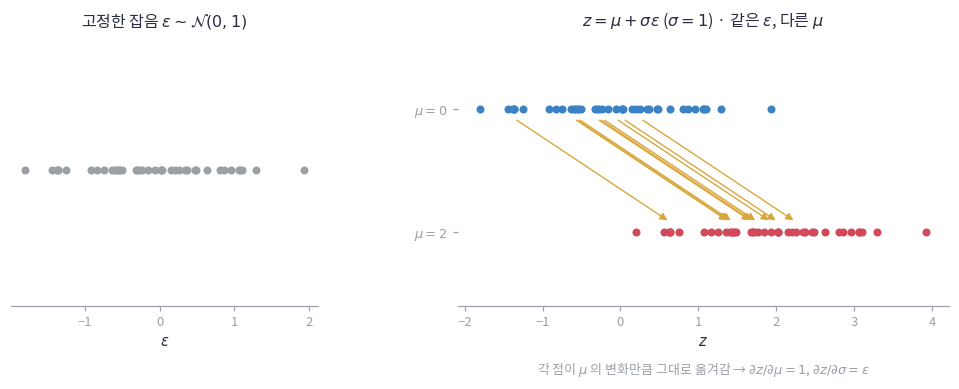

In [32]:
plot_reparameterization(rep_eps, rep_z_a, rep_z_b, 0., 2., rep_sigma)

🔍 **확인** · 잡음을 고정하면 $\mu$를 2만큼 옮길 때 모든 샘플이 정확히 2만큼 옮겨갑니다. 그래서 $\partial z/\partial\mu=1$이고, $\sigma$를 바꾸면 각 점이 자기 $\epsilon$만큼 움직여 $\partial z/\partial\sigma=\epsilon$입니다. 아래 검산은 $\ell$에 대한 미분을 같은 잡음에서 중심차분과 대조합니다.

In [33]:
# 쓰는 것: rng (1절 검산 셀) · q_mu, q_logvar (5절 검산 셀)
fixed_noise = rng.normal(size=q_mu.shape)                   # (2, 2): 고정한 ε
sampled_z = q_mu + np.exp(.5 * q_logvar) * fixed_noise      # (2, 2): z = μ + e^{ℓ/2} ε
upstream = rng.normal(size=q_mu.shape)                      # (2, 2): 임의의 상류 기울기 G
reparameterized_dlogvar = .5 * upstream * np.exp(.5 * q_logvar) * fixed_noise   # (2, 2): dℓ = G ⊙ ε ⊙ e^{ℓ/2} / 2


def reparam_scalar():
    """검사기용: 스칼라 L = Σ z ⊙ G (같은 잡음)."""
    return np.sum((q_mu + np.exp(.5*q_logvar)*fixed_noise) * upstream)


reparam_error = rel_error(reparameterized_dlogvar, numerical_gradient(reparam_scalar, q_logvar))   # q_logvar를 흔들어 잰 중심차분과 비교
assert reparam_error < 1e-7, "재매개화 미분의 상대오차가 1e−7 아래여야 합니다"
print('고정 잡음에서 재매개화 미분 오차:', reparam_error)

고정 잡음에서 재매개화 미분 오차: 4.907776033896594e-10


## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 잡음을 상관 있는 점으로 (1절)

평균 `mu` $(D,)$, 아래삼각 `L` $(D,D)$, 표준정규 잡음 `eps` $(N,D)$에서 샘플 `X`를 만드는 한 줄을 채우세요.

In [34]:
def exercise_sample(mu, L, eps):
    """연습 A: 잡음을 상관 있는 점으로. mu: (D,), L: (D, D) 아래삼각, eps: (N, D) 표준정규 → X: (N, D)."""
    assert eps.shape[1] == L.shape[0] == len(mu), "잡음·L·평균의 차원 D가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: X = 행에 저장한 잡음에 L 의 전치를 곱하고 mu 를 더한 값 (N, D)
    ### 힌트: 1절의 epsilon @ L.T + mu
    raise NotImplementedError
    return X

In [35]:
def check_sample(candidate):
    """1절 그림의 점과 50,000점의 경험 공분산으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: flow_mu, flow_L, flow_eps, flow_x (1절 그림 셀) · mu, L_hand, Sigma (1절 검산 셀)
    np.testing.assert_allclose(candidate(flow_mu, flow_L, flow_eps), flow_x)                        # 검산: 1절 그림의 점
    X_c = candidate(mu, L_hand, np.random.default_rng(3).normal(size=(50000, 2)))
    cov_c = (X_c - X_c.mean(axis=0)).T @ (X_c - X_c.mean(axis=0)) / len(X_c)
    np.testing.assert_allclose(cov_c, Sigma, atol=0.08)                                             # 검산: 경험 공분산 ≈ L Lᵀ
    np.testing.assert_allclose(X_c.mean(axis=0), mu, atol=0.03)                                     # 검산: 표본 평균 ≈ μ
    print("샘플 생성: 1절 그림·공분산 L Lᵀ 과 일치합니다.")

run_check(check_sample, exercise_sample, hint="X = eps @ L.T + mu")

☐ exercise_sample: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: X = eps @ L.T + mu


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
X = eps @ L.T + mu
```

</details>

### ✏️ 연습 B · 이산 KL (3절)

양수 확률 벡터 `p`, `q`에서 $D_{KL}(p\|q)=\sum_ip_i\log(p_i/q_i)$ 한 줄을 채우세요. 평균은 `p`로 냅니다.

In [36]:
def exercise_categorical_kl(p, q):
    """연습 B: 이산 KL D_KL(p‖q) = Σ p_i log(p_i/q_i). p, q: (K,) 양수 확률 벡터 → 숫자 하나."""
    assert np.all(p > 0) and np.all(q > 0), "이 연습은 모든 확률이 양수인 경우만 다룹니다"
    assert np.isclose(p.sum(), 1) and np.isclose(q.sum(), 1), "p, q의 합은 1이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: kl = p 로 가중한 log(p/q) 의 합
    ### 힌트: np.sum(p * (np.log(p) - np.log(q)))
    raise NotImplementedError
    return kl

In [37]:
def check_categorical_kl(candidate):
    """3절 손계산, 본문 categorical_kl, 비대칭·비음수, H(p,q) − H(p)로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: p, q, hand_kl (3절 검산 셀) · categorical_kl, cross_entropy, entropy (3절) · ent_vague, ent_sure (3절 그림 셀)
    np.testing.assert_allclose(candidate(p, q), hand_kl)                                           # 검산: 3절 손계산
    np.testing.assert_allclose(candidate(p, q), categorical_kl(p, q))                              # 검산: 본문 함수와 같음
    assert not np.isclose(candidate(p, q), candidate(q, p)), "순서를 바꾸면 값이 달라야 합니다"
    assert candidate(p, q) > 0, "p ≠ q이면 KL은 양수여야 합니다"
    np.testing.assert_allclose(candidate(ent_vague, ent_vague), 0, atol=1e-15)                     # 검산: 같은 분포면 0
    np.testing.assert_allclose(candidate(np.eye(10)[7] * 0.99 + 0.001, ent_sure), cross_entropy(np.eye(10)[7] * 0.99 + 0.001, ent_sure) - entropy(np.eye(10)[7] * 0.99 + 0.001))   # 검산: KL = H(p, q) − H(p)
    print("이산 KL: 손계산·H(p,q) − H(p) 와 일치합니다.")

run_check(check_categorical_kl, exercise_categorical_kl, hint="kl = np.sum(p * (np.log(p) - np.log(q)))")

☐ exercise_categorical_kl: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: kl = np.sum(p * (np.log(p) - np.log(q)))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
kl = np.sum(p * (np.log(p) - np.log(q)))
```

</details>

### ✏️ 연습 C · 대각 NLL의 기울기 (4절)

관측 `X` $(N,D)$, 평균 `mu`, 로그 분산 `logvar`에서 두 기울기를 만드는 두 줄을 채우세요. 관측 축에서 평균냅니다.

In [38]:
def exercise_nll_gradients(X, mu, logvar):
    """연습 C: 대각 NLL의 두 기울기. X: (N, D), mu, logvar: (D,) → (dmu: (D,), dlogvar: (D,))."""
    residual = mu - X                                                  # (N, D)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dmu = residual 의 관측 평균 × e^{−logvar}, dlogvar = ½ [1 − residual² 의 관측 평균 × e^{−logvar}]
    ### 힌트: 4절의 두 미분 식. np.exp(-logvar), residual.mean(axis=0), (residual ** 2).mean(axis=0)
    raise NotImplementedError
    return dmu, dlogvar

In [39]:
def check_nll_gradients(candidate):
    """본문 diagonal_nll, MLE에서 기울기 0, 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: X_fit (4절 학습 셀) · diagonal_nll (4절)
    mu_c, lv_c = np.array([-.3, .4]), np.array([.2, -.1])
    dmu_c, dlv_c = candidate(X_fit, mu_c, lv_c)
    _, dmu_ref, dlv_ref = diagonal_nll(X_fit, mu_c, lv_c)
    np.testing.assert_allclose(dmu_c, dmu_ref)                                                     # 검산: 본문 함수의 dmu
    np.testing.assert_allclose(dlv_c, dlv_ref)                                                     # 검산: 본문 함수의 dlogvar
    np.testing.assert_allclose(candidate(X_fit, X_fit.mean(axis=0), np.log(X_fit.var(axis=0)))[0], 0, atol=1e-12)   # 검산: MLE 에서 기울기 0

    def nll_at_lv():
        """검사기용: 로그 분산 lv_c에서의 NLL."""
        return diagonal_nll(X_fit, mu_c, lv_c)[0]

    num_c = numerical_gradient(nll_at_lv, lv_c)
    assert rel_error(dlv_c, num_c) < 1e-7, "dlogvar가 중심차분과 1e−7 안에서 같아야 합니다"
    print("NLL 기울기: diagonal_nll·중심차분과 일치하고 MLE 에서 0입니다.")

run_check(check_nll_gradients, exercise_nll_gradients, hint="dmu = residual.mean(axis=0) * np.exp(-logvar); dlogvar = 0.5 * (1 - (residual ** 2).mean(axis=0) * np.exp(-logvar))")

☐ exercise_nll_gradients: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dmu = residual.mean(axis=0) * np.exp(-logvar); dlogvar = 0.5 * (1 - (residual ** 2).mean(axis=0) * np.exp(-logvar))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dmu = residual.mean(axis=0) * np.exp(-logvar)
dlogvar = 0.5 * (1 - (residual ** 2).mean(axis=0) * np.exp(-logvar))
```

</details>

### ✏️ 연습 D · 표준정규 기준의 KL (5절)

$p=\mathcal N(0,I)$일 때 `q_mu`, `q_logvar` $(N,D)$에서 관측 평균 KL 한 줄을 채우세요.

In [40]:
def exercise_kl_standard(q_mu, q_logvar):
    """연습 D: p = N(0, I) 기준의 관측 평균 KL. q_mu, q_logvar: (N, D) → 숫자 하나."""
    assert q_mu.shape == q_logvar.shape, "평균과 로그 분산은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: kl = ½ · 관측 평균 [ 좌표 합 (μ² + e^{ℓ} − 1 − ℓ) ]
    ### 힌트: 5절 마지막 식. np.sum(..., axis=1) 뒤 np.mean
    raise NotImplementedError
    return kl

In [41]:
def check_kl_standard(candidate):
    """본문 diagonal_kl(p = 표준정규), q = p, 평균만 옮긴 손계산으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: q_mu, q_logvar (5절 검산 셀) · diagonal_kl (5절)
    np.testing.assert_allclose(candidate(q_mu, q_logvar), diagonal_kl(q_mu, q_logvar, np.zeros(2), np.zeros(2))[0])   # 검산: 본문 함수
    np.testing.assert_allclose(candidate(np.zeros((3, 4)), np.zeros((3, 4))), 0, atol=1e-15)                        # 검산: q = p 면 0
    np.testing.assert_allclose(candidate(np.array([[1.]]), np.array([[0.]])), 0.5)                                    # 검산: 평균 1만 옮기면 ½·1²
    print("표준정규 기준 KL: diagonal_kl 과 일치합니다.")

run_check(check_kl_standard, exercise_kl_standard, hint="kl = 0.5 * np.mean(np.sum(q_mu ** 2 + np.exp(q_logvar) - 1 - q_logvar, axis=1))")

☐ exercise_kl_standard: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: kl = 0.5 * np.mean(np.sum(q_mu ** 2 + np.exp(q_logvar) - 1 - q_logvar, axis=1))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
kl = 0.5 * np.mean(np.sum(q_mu ** 2 + np.exp(q_logvar) - 1 - q_logvar, axis=1))
```

</details>

### 🔍 완성 예제 · 기준 분포의 분산과 평균 이동의 비용

아래 검사기는 KL의 방향·로그 분산·두 미분·관측 평균을 확인합니다. `diagonal_kl`을 넣어 통과시킨 뒤, $q$의 평균만 움직일 때 기준 분포 $p$의 분산에 따라 KL이 어떻게 달라지는지 봅니다.

In [42]:
def check_diagonal_kl(candidate):
    """diagonal_kl 후보를 두 크기에서 검사: 반환 모양, 본문과 같은 값, 두 미분(중심차분), 관측을 두 배로 되풀이했을 때의 평균·기울기. 통과하면 문자열을 돌려줍니다."""
    # 쓰는 것: diagonal_kl (5절)
    local_rng = np.random.default_rng(127)
    for N, D in [(1, 3), (4, 2)]:
        qm = local_rng.normal(size=(N, D))
        ql = local_rng.normal(size=(N, D)) * .4
        pm = local_rng.normal(size=D)
        pl = local_rng.normal(size=D) * .6
        value, dm, dl = candidate(qm.copy(), ql.copy(), pm.copy(), pl.copy())
        assert np.ndim(value) == 0, "KL 값은 숫자 하나여야 합니다"
        assert np.shape(dm) == qm.shape, "dmu는 q_mu와 같은 모양이어야 합니다"
        assert np.shape(dl) == ql.shape, "dlogvar는 q_logvar와 같은 모양이어야 합니다"
        reference = diagonal_kl(qm, ql, pm, pl)[0]
        np.testing.assert_allclose(value, reference, rtol=1e-10, atol=1e-12)                       # 검산: 본문 함수와 같음

        def scalar():
            """검사기용: 본문 함수의 KL 값."""
            return diagonal_kl(qm, ql, pm, pl)[0]

        for analytic, parameter in [(dm, qm), (dl, ql)]:
            numeric = numerical_gradient(scalar, parameter)
            assert rel_error(analytic, numeric) < 1e-7, "기울기가 중심차분과 1e−7 안에서 같아야 합니다"
        repeated_value, repeated_dm, repeated_dl = candidate(np.repeat(qm, 2, axis=0), np.repeat(ql, 2, axis=0), pm, pl)
        np.testing.assert_allclose(repeated_value, value)                                          # 검산: 관측을 두 배로 해도 평균은 그대로
        np.testing.assert_allclose(repeated_dm, np.repeat(dm, 2, axis=0) / 2)                      # 검산: 관측별 기울기는 절반 (N이 두 배)
        np.testing.assert_allclose(repeated_dl, np.repeat(dl, 2, axis=0) / 2)                      # 검산: dlogvar도 절반
    return '통과: KL 방향·로그 분산·두 미분·관측 평균'

In [43]:
# 쓰는 것: diagonal_kl (5절)
print(check_diagonal_kl(diagonal_kl))
means = np.linspace(-2, 2, 101)                             # (101,): q의 평균 μ_q
kl_by_variance = {}                                         # 그림용: p 분산 → μ_q마다의 KL
for p_variance in [.5, 1., 2.]:
    kl_by_variance[f'p 분산 {p_variance}'] = [
        diagonal_kl(np.array([[m]]), np.array([[0.]]), np.array([0.]), np.log([p_variance]))[0]   # q = N(m, 1), p = N(0, p_variance)
        for m in means]

통과: KL 방향·로그 분산·두 미분·관측 평균


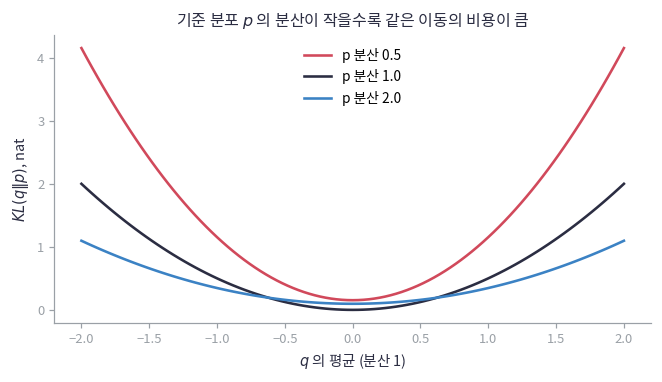

In [44]:
plot_kl_vs_mean(means, kl_by_variance)

🔍 **확인** · 분산이 작은 $p$는 같은 거리의 평균 이동에 더 큰 비용을 줍니다. $(\mu_q-\mu_p)^2/e^{\ell_p}$ 항의 분모가 작기 때문입니다. VAE에서 사전분포를 표준정규로 두면 이 곡선이 잠재 평균을 0 근처로 당기는 힘입니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 다섯 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- 행에 저장한 표준정규 샘플에 `L.T`를 곱하는 이유를 공분산으로 확인할 수 있나요? → 1절
- 분산의 로그 $\ell$에서 표준편차가 왜 $e^{\ell/2}$인지 설명할 수 있나요? → 4·6절
- $H(p,q)=H(p)+KL(p\|q)$와 분류 CE의 관계를 손계산할 수 있나요? → 3절
- 평균 NLL을 사용할 때 사전 항의 계수가 어떻게 달라지는지 유도할 수 있나요? → 4절
- Gaussian KL의 기대값을 어느 분포로 계산하는지, 어떤 축을 평균하는지 말할 수 있나요? → 5절

다음 [13 자동미분](13_autodiff.ipynb)에서 이런 국소 미분을 그래프에 연결하고 PyTorch와 대조합니다.
VAE 단원에서는 여기의 Gaussian KL·재매개화에 잠재변수 모형과 ELBO 유도를 연결합니다.

📎 참고: [Stanford CS229 다변량 Gaussian](https://cs229.stanford.edu/section/gaussians.pdf)의 밀도·공분산,
[Kingma·Welling의 VAE 원논문](https://arxiv.org/abs/1312.6114)의 대각 Gaussian KL과 재매개화.